# EDA + Lista de Leakage — Bank Marketing

**Etapa E1 · Eng. de Dados.** Objetivo: entender a base *antes* de modelar, expor o
desbalanceamento e os valores ausentes disfarçados, e **identificar features de vazamento
temporal (leakage)** a serem removidas.

- **Base:** data/kaggle/bank-additional-full.csv (41.188 × 21) — ver
  [dicionário de dados](../docs/data-dictionary.md).
- **Atenção:** esta variante (*bank-additional*) **não tem coluna balance (saldo)**;

## 1. Setup e carga

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
from kaggle.api.kaggle_api_extended import KaggleApi

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

ModuleNotFoundError: No module named 'bm'

In [2]:
def download_dataset_kaggle(dataset: str, destination: Path) -> None:
    try:
        api = KaggleApi()
        api.authenticate()
    except Exception as ex:
        print(ex)
        return None
    try:
        api.dataset_download_files(
            dataset,
            path=str(destination),
            unzip=True,
            quiet=True,
        )
    except Exception as e:
        print(e)

    return None

In [3]:
DATA = Path("../data/raw/bank-additional-full.csv")

In [4]:
if not DATA.exists():
    download_dataset_kaggle("henriqueyamahata/bank-marketing", DATA)

df = pd.read_csv(DATA, sep=";")

print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")

df.head()

Base carregada: 41188 linhas x 21 colunas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1.1 Sanidade da carga

O arquivo usa separador `;` (não vírgula) — ler errado corrompe todo o pipeline rio abaixo.
Travamos o shape esperado num `assert` e checamos duplicatas.

In [5]:
assert df.shape == (41188, 21), f"shape inesperado: {df.shape}"

n_dup = df.duplicated().sum()
print(f"duplicatas exatas: {n_dup}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"apos remocao: {df.shape[0]} linhas x {df.shape[1]} colunas")

duplicatas exatas: 12
apos remocao: 41176 linhas x 21 colunas


In [6]:
df.query("poutcome != 'nonexistent'").poutcome.value_counts(normalize=True).round(2)*100

poutcome
failure    76.0
success    24.0
Name: proportion, dtype: float64

## 2. Visão geral — shape, tipos e estatísticas

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

Aqui percebemos que não existem valores nulos, investigar.

### Estatísticas das numéricas.

**Cuidado:** duration é leakage e pdays maioria de valores = 999.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


### Cardinalidade das categóricas

In [9]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.drop("y")

df[cat_cols].nunique().sort_values(ascending=False).to_frame("n_categorias")

,n_categorias
job,12
month,10
education,8
day_of_week,5
marital,4
default,3
loan,3
housing,3
poutcome,3
contact,2


## 3. Valores ausentes — o "unknown" disfarçado

Esta base **não tem NaN**: o ausente vem como a string "unknown".

In [10]:
df = df.replace("unknown", pd.NA)
miss = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame()
    .rename(columns={0: "missing"})
    .query("missing > 0")
)
miss["pct_missing"] = miss.apply(lambda x: (x / len(df) * 100).round(2))
miss

,missing,pct_missing
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             40846 non-null  object 
 2   marital         41096 non-null  object 
 3   education       39446 non-null  object 
 4   default         32580 non-null  object 
 5   housing         40186 non-null  object 
 6   loan            40186 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

In [12]:
df[df["housing"].isna()][["housing", "loan"]]

,housing,loan
29,<NA>,<NA>
81,<NA>,<NA>
261,<NA>,<NA>
385,<NA>,<NA>
401,<NA>,<NA>
...,...,...
40978,<NA>,<NA>
41002,<NA>,<NA>
41003,<NA>,<NA>
41017,<NA>,<NA>


housing e loan têm exatamente o mesmo nº de ausentes e ocorrem juntos

## 4. Variável alvo y — desbalanceamento

In [13]:
y_dist = df.y.value_counts(normalize=True).mul(100).round(2)

print(y_dist.to_string())


y
no     88.73
yes    11.27


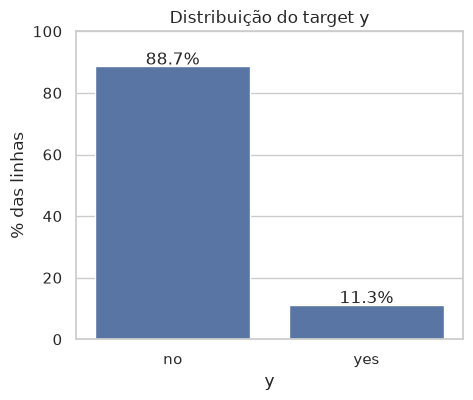

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=y_dist.index, y=y_dist.values, ax=ax)
for i, v in enumerate(y_dist.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set(
    title="Distribuição do target y", ylabel="% das linhas", xlabel="y", ylim=(0, 100)
)
plt.show()

Apenas **~11% de yes**. Isso indica necessidade de desbalanceamento (PR-AUC, recall, F1)

## 5. Distribuições e relação com o target

### 5.1 age por y

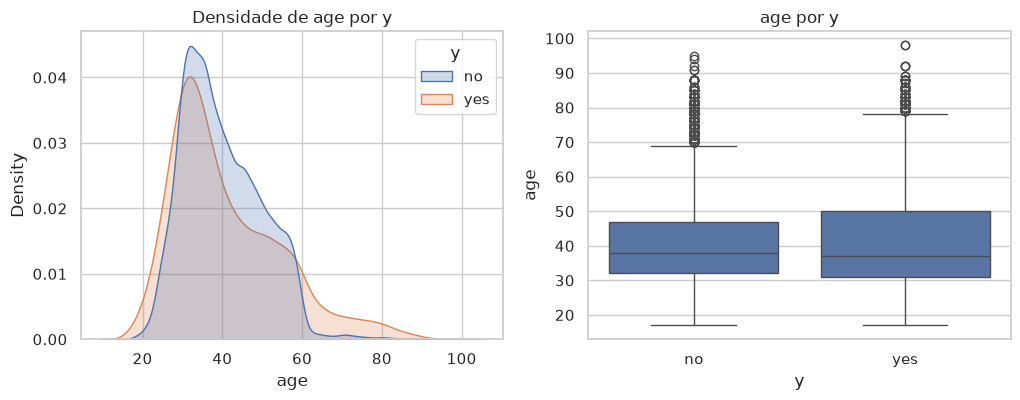

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="age", hue="y", common_norm=False, fill=True, ax=axes[0])
axes[0].set_title("Densidade de age por y")
sns.boxplot(data=df, x="y", y="age", ax=axes[1])
axes[1].set_title("age por y")
plt.show()

### 5.2 Conversão por job

Taxa de yes por profissão vs. a média global (11,3%) — insumo para o contexto sintético
(proxy de renda/segmento).

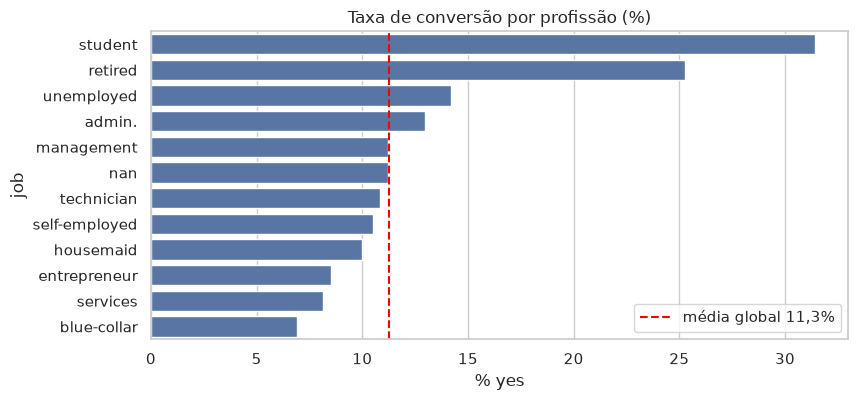

In [16]:
df["y_bin"] = (df.y == "yes").astype(int)
conv_job = (
    df.groupby("job", dropna=False).y_bin.mean().mul(100).sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=conv_job.values, y=conv_job.index.astype(str), ax=ax)
ax.axvline(11.27, ls="--", color="red", label="média global 11,3%")
ax.set(title="Taxa de conversão por profissão (%)", xlabel="% yes")
ax.legend()
plt.show()

### 5.3 default / housing / loan — proxies de capacidade financeira

In [17]:
print(df["default"].value_counts(normalize=True).mul(100).round(2), end="\n\n")
print(
    df.groupby("loan")["y"].value_counts(normalize=True).mul(100).round(2), end="\n\n"
)
print(
    df.groupby("housing")["y"].value_counts(normalize=True).mul(100).round(2),
    end="\n\n",
)

default
no     99.99
yes     0.01
Name: proportion, dtype: float64

loan  y  
no    no     88.66
      yes    11.34
yes   no     89.07
      yes    10.93
Name: proportion, dtype: float64

housing  y  
no       no     89.12
         yes    10.88
yes      no     88.38
         yes    11.62
Name: proportion, dtype: float64



**Achado importante:** default = "yes" tem **apenas 3 linhas** em toda a base.

"negativado = default==yes" é um proxy praticamente vazio

"loan" e "housing" tem distribuições semelhantes em taxa de conversão.

## 6. pdays — sentinela 999

999 significa "cliente nunca contatado antes" — é categórico disfarçado de numérico.
Separamos em uma flag booleana foi_contatado_antes para não poluir estatísticas e modelos.

In [18]:
print("share de pdays == 999:", round((df.pdays == 999).mean(), 4))
df["foi_contatado_antes"] = df.pdays != 999
print("\nConversão (% yes) por foi_contatado_antes:")
print(df.groupby("foi_contatado_antes").y_bin.mean().mul(100).round(2).to_string())

share de pdays == 999: 0.9632

Conversão (% yes) por foi_contatado_antes:
foi_contatado_antes
False     9.26
True     63.83


## 7. Vazamento temporal (leakage)

### 7.1 duration — a prova

duration (duração da ligação) só é conhecida **depois** que a ligação termina — quando o
desfecho já é sabido. O gráfico mostra a separação gritante (média 221s para no vs 553s
para yes; correlação 0,40). **Deve ser removida** do conjunto de modelagem.

y
no     220.9
yes    553.3
corr(duration, y): 0.405


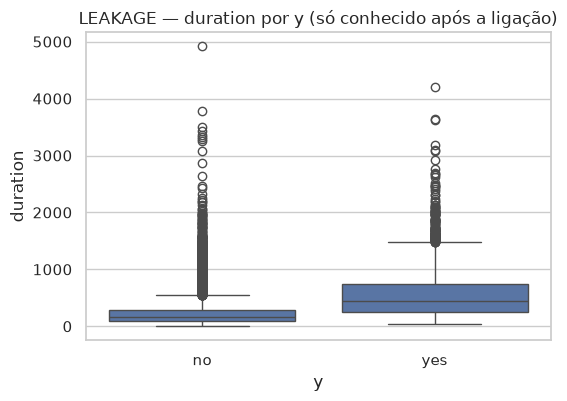

In [19]:
print(df.groupby("y").duration.mean().round(1).to_string())
print("corr(duration, y):", round(df.duration.corr(df.y_bin), 3))
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="y", y="duration", ax=ax)
ax.set_title("LEAKAGE — duration por y (só conhecido após a ligação)")
plt.show()

### 7.2 Indicadores macro — colinearidade e viés temporal

emp.var.rate, euribor3m e nr.employed são quase perfeitamente colineares (0,91–0,97):
codificam *quando* a campanha rodou (regime econômico 2008–2010), não o cliente. Risco de o
modelo aprender "a época" em vez de propensão → **candidatos secundários a leakage temporal**.

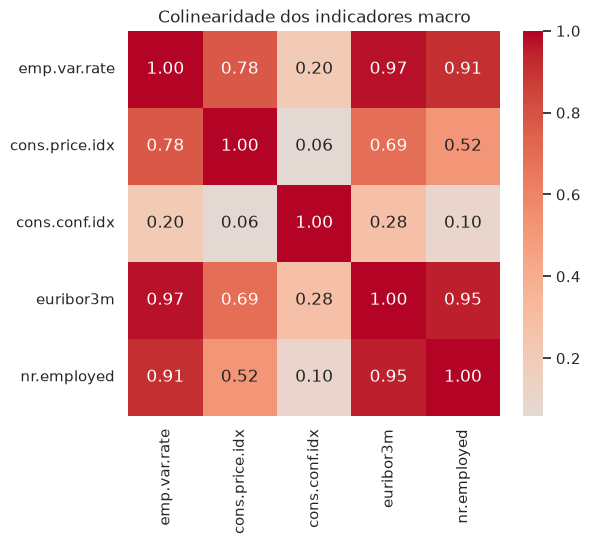

In [20]:
macro = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[macro].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Colinearidade dos indicadores macro")
plt.show()

## 8. Associações entre todas as variáveis (dython)

dython.associations lida com tipos mistos: **Cramér's V** para categórica×categórica e
**correlation ratio (η)** para categórica×numérica — superior a um .corr() que ignoraria as
categóricas. Repare na linha/coluna de duration vs y: a associação alta é justamente o
leakage.

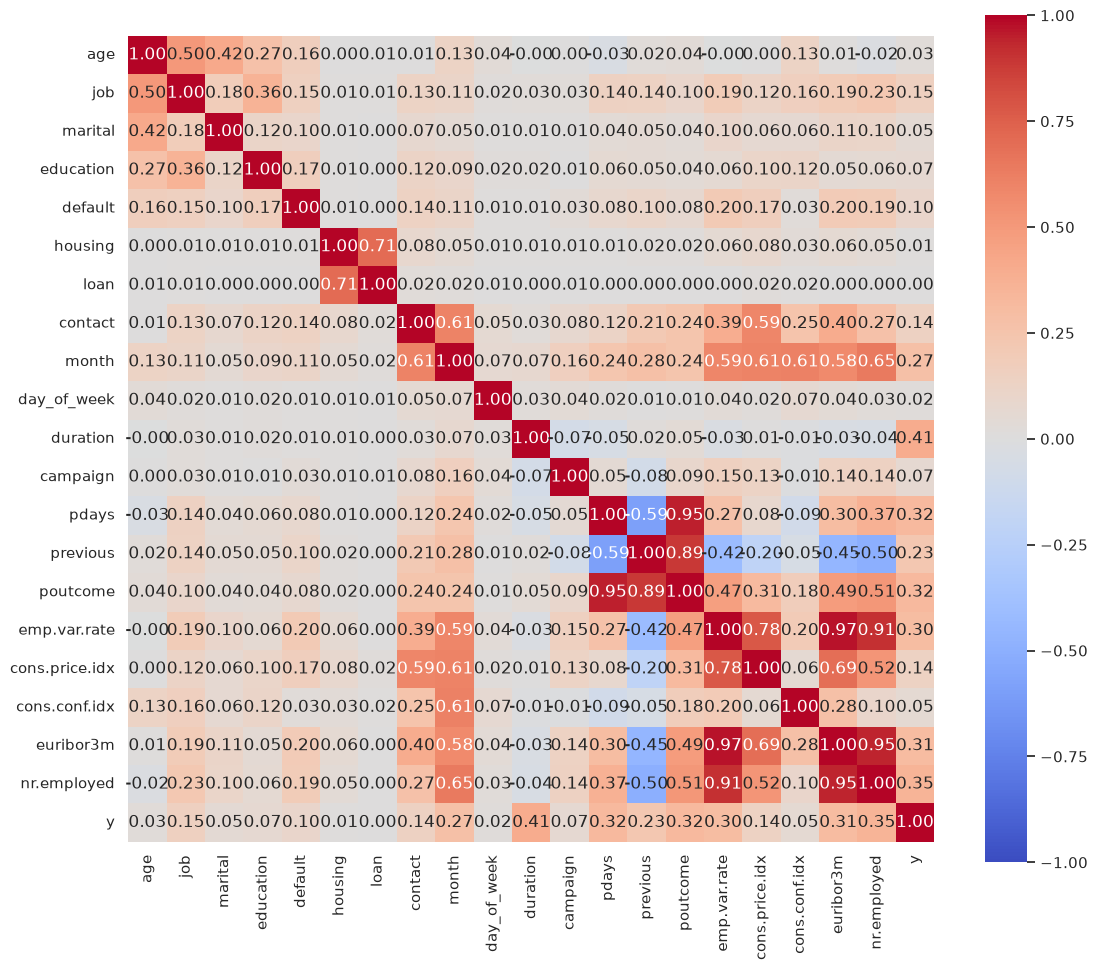

In [21]:
assoc = associations(
    df.drop(columns=["y_bin", "foi_contatado_antes"]),
    nom_nom_assoc="cramer",
    nan_strategy="replace",
    nan_replace_value="ausente",
    figsize=(13, 11),
    cmap="coolwarm",
)
plt.show()

## 9. Features candidatas a leakage

| # | Feature | Veredito | Justificativa |
|---|---------|----------|---------------|
| 1 | duration | **Remover** | Só existe após a ligação; prevê o passado com info do futuro. Corr 0,40 com y; média 221s (no) × 553s (yes). |
| 2 | pdays (=999) | **Transformar** | 96% sentinela 999; usar como flag foi_contatado_antes, não como número cru. |
| 3 | emp.var.rate, euribor3m, nr.employed | **Vigiar / regularizar** | Colineares (0,91–0,97) e proxies do período temporal; risco de o modelo aprender o regime econômico. Avaliar manter só 1 ou nenhum. |
| 4 | poutcome / previous | **Avaliar** | Legítimos (campanha anterior), mas confirmar que não carregam o desfecho atual. |

## 10. Conclusões e próximos passos

- Base com **~11% de positivos** → métricas sensíveis a desbalanceamento.
- Ausentes disfarçados de "unknown"; default (21%) e education (4%) os mais afetados.
- **default="yes" quase inexistente (3 linhas)** → revisar o proxy de "negativado" da E2.
- **duration é o leakage nº 1** e sai do conjunto de modelagem.
- pdays=999 vira flag; indicadores macro ficam sob vigilância (colinearidade/viés temporal).



## 11. Análise por braço — definindo as ações do bandit

Esta é a decisão estrutural do projeto: **o que é um braço (arm)?** O bandit não escolhe
"qual cliente contatar", ele escolhe **qual ação tomar** para o cliente que chegou. O dataset
tem uma única oferta (depósito a prazo), então os braços vêm do **canal de contato**:

> **Decisão do grupo: os braços são `contact` — `cellular` vs `telephone` → 2 braços.**
> A recompensa é binária: `y == "yes"` → 1, caso contrário 0.

Consideramos cruzar com `day_of_week` (o que daria 2 × 5 = 10 braços) e **testamos a hipótese
formalmente** na seção 11.1 antes de rejeitá-la: o sinal do dia é real dentro do `cellular`, mas
o bandit não teria dados suficientes para *resolver* os braços resultantes, e o cruzamento
descartaria 80% da amostra útil do replay. O `day_of_week` vai para o **contexto**, não para os
braços.

Abaixo medimos a conversão de cada candidato para justificar a escolha com dados, não com
achismo. Um braço só é interessante se houver **diferença real de recompensa** entre as opções —
senão não há nada para o bandit descobrir.

In [22]:
# Taxa de conversao por braco candidato: contact
por_contact = (
    df.groupby("contact")
    .agg(n=("y_bin", "size"), conversao_pct=("y_bin", lambda s: s.mean() * 100))
    .sort_values("conversao_pct", ascending=False)
    .round(2)
)
print("Conversao por contact (BRACOS DO BANDIT):")
print(por_contact.to_string())

lift = por_contact.conversao_pct.iloc[0] / por_contact.conversao_pct.iloc[-1]
print(f"\nMelhor braco converte {lift:.1f}x mais que o pior.")

Conversao por contact (BRACOS DO BANDIT):
               n  conversao_pct
contact                        
cellular   26135          14.74
telephone  15041           5.23

Melhor braco converte 2.8x mais que o pior.


Conversao por day_of_week (NAO usado como braco):
day_of_week
thu    12.11
tue    11.79
wed    11.67
fri    10.81
mon     9.95

amplitude day_of_week: 2.2 p.p.
amplitude contact:     9.5 p.p.


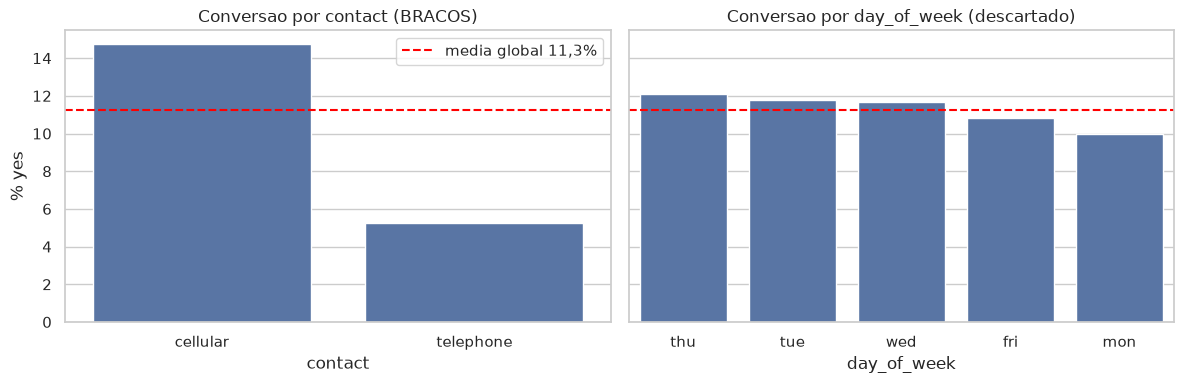

In [23]:
# Por que day_of_week NAO vira braco: variacao pequena comparada a contact
por_dia = (
    df.groupby("day_of_week")
    .y_bin.mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)
print("Conversao por day_of_week (NAO usado como braco):")
print(por_dia.to_string())
print(f"\namplitude day_of_week: {por_dia.max() - por_dia.min():.1f} p.p.")
print(
    f"amplitude contact:     "
    f"{por_contact.conversao_pct.max() - por_contact.conversao_pct.min():.1f} p.p."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.barplot(
    x=por_contact.index.astype(str), y=por_contact.conversao_pct.values, ax=axes[0]
)
axes[0].axhline(11.27, ls="--", color="red", label="media global 11,3%")
axes[0].set(title="Conversao por contact (BRACOS)", ylabel="% yes", xlabel="contact")
axes[0].legend()

sns.barplot(x=por_dia.index.astype(str), y=por_dia.values, ax=axes[1])
axes[1].axhline(11.27, ls="--", color="red")
axes[1].set(title="Conversao por day_of_week (descartado)", xlabel="day_of_week")
plt.tight_layout()
plt.show()

### 11.1 Testamos cruzar `contact` × `day_of_week` — e rejeitamos. Por quê?

O cruzamento daria 2 × 5 = **10 braços**. É uma hipótese razoável, então a testamos de verdade
em vez de descartar por intuição. Três perguntas, nesta ordem:

1. O dia da semana tem efeito **dentro** de cada canal, ou é ruído?
2. Se tem, o bandit conseguiria **resolver** esses braços com os dados que existem?
3. Qual o custo do cruzamento na simulação de replay?

In [24]:
# Pergunta 1: os 10 bracos hipoteticos, com intervalo de confianca de 95%.
# O IC e o que revela se dois bracos sao mesmo distinguiveis ou se apenas parecem diferentes.
from scipy import stats

g10 = df.groupby(["contact", "day_of_week"]).agg(
    n=("y_bin", "size"), conv=("y_bin", "mean")
)
g10["conv_pct"] = (g10.conv * 100).round(2)
g10["se_pp"] = (np.sqrt(g10.conv * (1 - g10.conv) / g10.n) * 100).round(2)
g10["ic95"] = g10.apply(
    lambda r: f"[{r.conv_pct - 1.96 * r.se_pp:.1f}, {r.conv_pct + 1.96 * r.se_pp:.1f}]",
    axis=1,
)

print("Os 10 bracos hipoteticos (contact x day_of_week):")
print(g10[["n", "conv_pct", "ic95"]].sort_values("conv_pct", ascending=False).to_string())

Os 10 bracos hipoteticos (contact x day_of_week):
                          n  conv_pct          ic95
contact   day_of_week                              
cellular  tue          5104     15.77  [14.8, 16.8]
          thu          5802     15.36  [14.4, 16.3]
          wed          5052     15.28  [14.3, 16.3]
          fri          4644     14.56  [13.5, 15.6]
          mon          5533     12.80  [11.9, 13.7]
telephone wed          3082      5.74    [4.9, 6.6]
          thu          2816      5.43    [4.6, 6.3]
          fri          3182      5.34    [4.6, 6.1]
          tue          2982      4.96    [4.2, 5.7]
          mon          2979      4.67    [3.9, 5.4]


In [25]:
# Pergunta 1 (cont.): o dia importa DENTRO de cada canal, ou e ruido?
# Qui-quadrado de independencia entre day_of_week e a conversao, canal a canal.
print("O dia da semana tem efeito dentro de cada canal?\n")
for c in ["cellular", "telephone"]:
    sub = df[df.contact == c]
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(sub.day_of_week, sub.y_bin))
    spread = sub.groupby("day_of_week").y_bin.mean() * 100
    veredito = "SIGNIFICATIVO" if p < 0.05 else "ruido"
    print(
        f"  {c:10} amplitude={spread.max() - spread.min():.1f} p.p. | "
        f"chi2={chi2:5.1f} | p={p:.4f} -> {veredito}"
    )

chi2_c, p_c, _, _ = stats.chi2_contingency(pd.crosstab(df.contact, df.y_bin))
print(f"\n  (referencia) contact: chi2={chi2_c:.1f} | p={p_c:.3g}")
print("\n  -> o canal domina o dia em DUAS ORDENS DE GRANDEZA de chi2.")

O dia da semana tem efeito dentro de cada canal?

  cellular   amplitude=3.0 p.p. | chi2= 24.0 | p=0.0001 -> SIGNIFICATIVO
  telephone  amplitude=1.1 p.p. | chi2=  4.3 | p=0.3681 -> ruido

  (referencia) contact: chi2=862.1 | p=1.72e-189

  -> o canal domina o dia em DUAS ORDENS DE GRANDEZA de chi2.


In [26]:
# Perguntas 2 e 3: o bandit CONSEGUIRIA resolver 10 bracos? E quanto custa no replay?
def n_por_braco(p1: float, p2: float, alpha: float = 0.05, power: float = 0.80) -> float:
    """Amostras necessarias POR BRACO para distinguir duas taxas de conversao (z-test)."""
    z_a, z_b = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
    pbar = (p1 + p2) / 2
    num = z_a * np.sqrt(2 * pbar * (1 - pbar)) + z_b * np.sqrt(
        p1 * (1 - p1) + p2 * (1 - p2)
    )
    return num**2 / (p1 - p2) ** 2


conv = g10.conv  # taxas reais observadas
contrastes = [
    ("cellular vs telephone (os 2 bracos escolhidos)", 0.1474, 0.0523),
    ("cellular/tue vs cellular/mon (melhor vs pior dia)", conv[("cellular", "tue")], conv[("cellular", "mon")]),
    ("cellular/tue vs cellular/thu (topo do ranking)", conv[("cellular", "tue")], conv[("cellular", "thu")]),
    ("cellular/tue vs cellular/wed (topo do ranking)", conv[("cellular", "tue")], conv[("cellular", "wed")]),
]

# No replay so contabilizamos a linha quando o braco escolhido == braco logado.
# Explorando K bracos, a taxa de match e ~1/K -> a amostra util encolhe com K.
N = len(df)
uteis = {K: N / K for K in (2, 10)}

print(f"{'contraste':<50} {'necessario/braco':>17} {'replay entrega':>15}   veredito")
print("-" * 100)
for nome, p1, p2 in contrastes:
    K = 2 if "os 2 bracos" in nome else 10
    precisa = n_por_braco(p1, p2)
    entrega = uteis[K] / K  # amostras uteis por braco
    ok = "VIAVEL" if entrega > precisa else f"IMPOSSIVEL (curto {precisa / entrega:.0f}x)"
    print(f"{nome:<50} {precisa:>17,.0f} {entrega:>15,.0f}   {ok}")

print()
print(f"Replay com  2 bracos: ~{uteis[2]:,.0f} amostras uteis de {N:,} linhas (~{uteis[2] / 2:,.0f}/braco)")
print(f"Replay com 10 bracos: ~{uteis[10]:,.0f} amostras uteis de {N:,} linhas (~{uteis[10] / 10:,.0f}/braco)")
print(f"\n-> o cruzamento JOGA FORA ~{(1 - uteis[10] / uteis[2]) * 100:.0f}% dos dados uteis do replay.")

contraste                                           necessario/braco  replay entrega   veredito
----------------------------------------------------------------------------------------------------
cellular vs telephone (os 2 bracos escolhidos)                   155          10,294   VIAVEL
cellular/tue vs cellular/mon (melhor vs pior dia)              2,169             412   IMPOSSIVEL (curto 5x)
cellular/tue vs cellular/thu (topo do ranking)               119,685             412   IMPOSSIVEL (curto 291x)
cellular/tue vs cellular/wed (topo do ranking)                85,447             412   IMPOSSIVEL (curto 208x)

Replay com  2 bracos: ~20,588 amostras uteis de 41,176 linhas (~10,294/braco)
Replay com 10 bracos: ~4,118 amostras uteis de 41,176 linhas (~412/braco)

-> o cruzamento JOGA FORA ~80% dos dados uteis do replay.


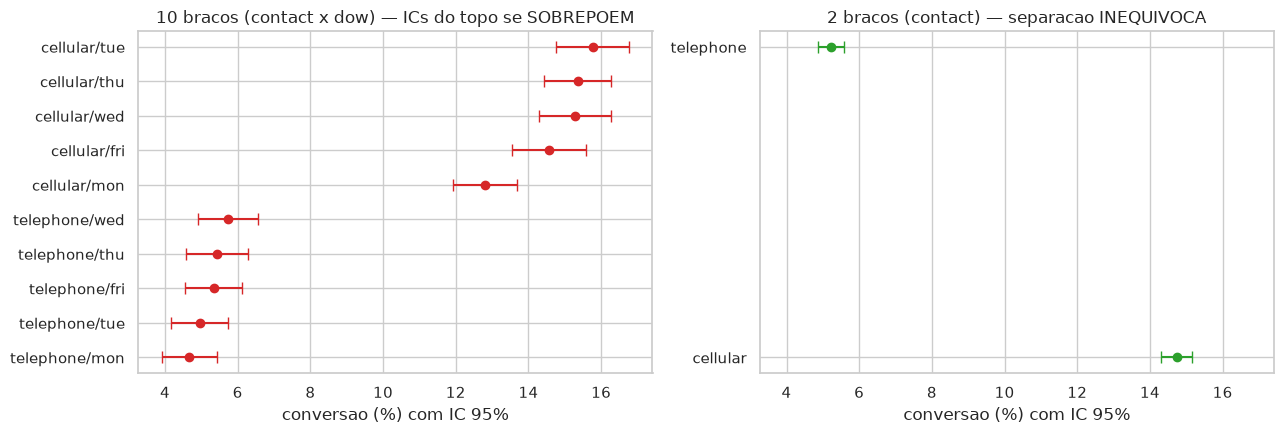

In [27]:
# A imagem do argumento: com 10 bracos os ICs do topo se sobrepoem -> o "melhor" braco
# nao e identificavel. Com 2 bracos a separacao e gritante.
p10 = g10.reset_index().assign(
    braco=lambda d: d.contact + "/" + d.day_of_week
).sort_values("conv_pct", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].errorbar(
    p10.conv_pct, p10.braco, xerr=1.96 * p10.se_pp, fmt="o", capsize=4, color="tab:red"
)
axes[0].set(
    title="10 bracos (contact x dow) — ICs do topo se SOBREPOEM",
    xlabel="conversao (%) com IC 95%",
)
axes[0].invert_yaxis()

p2 = por_contact.reset_index()
se2 = np.sqrt(
    (p2.conversao_pct / 100) * (1 - p2.conversao_pct / 100) / p2.n
) * 100
axes[1].errorbar(
    p2.conversao_pct, p2.contact, xerr=1.96 * se2, fmt="o", capsize=4, color="tab:green"
)
axes[1].set(
    title="2 bracos (contact) — separacao INEQUIVOCA",
    xlabel="conversao (%) com IC 95%",
)
axes[1].set_xlim(axes[0].get_xlim())
plt.tight_layout()
plt.show()

### Veredito do cruzamento: sinal real, mas **irresolvível** — vira contexto, não braço

**O sinal existe.** Dentro do `cellular`, o dia da semana é estatisticamente significativo
(χ² = 24,0, p = 0,0001): segunda converte 12,8% contra 15,8% na terça. Dentro do `telephone`, é
ruído (p = 0,37). Ou seja, não há um efeito "dia da semana" genérico — há um efeito
*"segunda-feira é ruim no celular"*. E o canal domina o dia em **duas ordens de grandeza** de χ²
(862 vs 24).

**Mas o bandit não conseguiria explorá-lo.** Os braços que disputam o topo — `cellular/tue`
(15,8%), `cellular/thu` (15,4%) e `cellular/wed` (15,3%) — têm ICs 95% que se sobrepõem quase
inteiramente. Para separar `tue` de `thu` com poder estatístico decente seriam necessárias
**~120.000 amostras por braço**; o dataset inteiro tem 41 mil linhas. Seriam precisos quase três
datasets completos dentro de um único braço.

**E o replay piora tudo.** Ele descarta as linhas em que o bandit escolhe um braço diferente do
histórico, então a amostra útil encolhe com o número de braços:

| Desenho | Amostras úteis no replay | Por braço | Necessário p/ separar o topo |
|---|---|---|---|
| **2 braços** (`contact`) | ~20.600 | ~10.300 | **155** → folga de 66x ✅ |
| 10 braços (`contact × dow`) | ~4.100 | ~412 | **~120.000** → curto ~290x ❌ |

Com 10 braços jogaríamos fora **80% dos dados úteis** em troca de um ranking de topo
indistinguível de sorteio. Nem o contraste mais fácil dentro do `cellular` (terça vs segunda,
o único de fato significativo) seria resolvível: precisaria de ~2.200 por braço e o replay
entregaria ~412. O bandit passaria a simulação inteira explorando braços empatados: o regret
sobe e o gráfico de convergência — a imagem principal da apresentação — vira um emaranhado sem
história.

**Decisão:** ficamos com **2 braços** (`contact`). O `day_of_week` **não é descartado** — ele vai
para o conjunto de **features de contexto**. Num bandit contextual (variante da Etapa 3), o
modelo aprende "para este cliente, numa segunda, o valor esperado do celular é menor" sem
fragmentar o espaço de ações: captura-se o sinal sem pagar o custo de 10 braços.

In [28]:
# Contrato de dados que a Etapa 2 (src/data_prep.py) e a Etapa 3 (bandit) consomem.
# Os bracos saem DOS DADOS, nao de uma lista escrita a mao.
BRACOS = sorted(df.contact.unique())

print("BRACOS =", BRACOS)
print("n_bracos =", len(BRACOS))
print("\nrecompensa: y == 'yes' -> 1, senao 0")
print("\nbaseline melhor braco historico (oraculo estatico):")
print(f"  {por_contact.index[0]} -> {por_contact.conversao_pct.iloc[0]:.2f}%")
print("baseline regra fixa ingenua (sempre o pior braco):")
print(f"  {por_contact.index[-1]} -> {por_contact.conversao_pct.iloc[-1]:.2f}%")

BRACOS = ['cellular', 'telephone']
n_bracos = 2

recompensa: y == 'yes' -> 1, senao 0

baseline melhor braco historico (oraculo estatico):
  cellular -> 14.74%
baseline regra fixa ingenua (sempre o pior braco):
  telephone -> 5.23%


### Conclusão da análise por braço

`cellular` converte **~14,7%** contra **~5,2%** de `telephone` — quase **3x**. É uma diferença
grande e clara, o que torna o problema de bandit interessante: **existe um braço melhor a ser
descoberto**, e o custo de explorar o braço errado é real.

Isso define os dois baselines de comparação da Etapa 3:

| Política | Conversão esperada |
|---|---|
| Regra fixa ingênua (sempre `telephone`) | ~5,2% |
| Melhor braço histórico (sempre `cellular`, oráculo estático) | ~14,7% |

O bandit deve **esmagar a regra fixa** e **convergir para perto do oráculo** — sem conhecê-lo
de antemão. Essa é a história que o projeto conta.